# Regime-Stratified Sensitivity Analysis — Level 5L6

Sensitivity of the L5L6 model **conditioned on the rate-limiting regime**
(surface- / oxide- / metal-limited), where **regime = argmax of the flux-weighted
resistance fractions** (`frac_surface`, `frac_oxide`, `frac_metal`).

**Method — targeted per-regime sampling:**
- **Phase 1:** one LHS scan per regime over a regime-favouring *preset* → label by
  argmax → keep the in-regime cluster.
- **Phase 2 (Route B):** given-data **PAWN** + **Borgonovo-δ** on the *true*
  cluster — valid on scattered points, zero extra model evaluations.
- **Phase 3:** cross-regime comparison of the δ / PAWN rankings.
- Heavy-tailed metrics (`flux`, `permeability`) analysed on **log10**; `theta` linear.

Given-data estimators are used throughout precisely because filtering a sample by
regime destroys the structured designs that Morris and Sobol require, while PAWN
and δ are valid on any scattered point cloud.

**Data is cached to CSV** (see `RESULTS_DIR`): the first run saves all model
evaluations and result tables; later runs **reload** them and skip the expensive
model calls. Set `FORCE_RECOMPUTE = True` (or delete `RESULTS_DIR`) to regenerate.

See [docs/regime_sensitivity_workflow.md](../docs/regime_sensitivity_workflow.md).
Run with the **`mace_env`** kernel. Note this env pins **`SALib==1.5.0`**: torch/mace-torch
hold numpy at 1.26.4, and SALib >= 1.5.1 calls `np.trapezoid` (a numpy-2.0 rename), which
breaks the Borgonovo-δ step.

In [1]:
import os, sys, importlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)

# repo root on path (mirrors the other notebooks)
parent_dir = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

In [2]:
import calculations.sensitivity as sens
importlib.reload(sens)
from calculations.config.model_config import (
    SUGGESTED_RANGES_LEVEL5L6, REGIME_PRESETS, DEFAULT_N_PER_REGIME
)
from calculations.sensitivity import (
    REGIME_SA_METRICS, run_targeted_regime_scans, load_regime_scans,
    plot_regime_exploration, givendata_sensitivity_by_regime, summarize_givendata,
    plot_givendata_results, regime_comparison_matrix, plot_regime_comparison_heatmap,
    plot_regime_geometry
)
PARAMS = list(SUGGESTED_RANGES_LEVEL5L6.keys())
print(f"{len(PARAMS)} parameters; regime presets: {list(REGIME_PRESETS)}")

36 parameters; regime presets: ['metal', 'surface', 'oxide']


In [3]:
# === Run configuration (scale these up for a production run) ==================
SEED            = 42
N_PER_REGIME    = {'metal': 1850, 'surface': 5250, 'oxide': 2010}  # LHS draws -> ~1500/cluster
TOP_K           = 8          # params kept for top-driver tables / geometry plot axes
METRICS         = ['flux', 'permeability', 'theta']

# === Data caching =============================================================
RESULTS_DIR     = "sa_results"     # all CSV outputs live here
FORCE_RECOMPUTE = False            # True (or delete RESULTS_DIR) to recompute from scratch
SCAN_DIR        = os.path.join(RESULTS_DIR, "scans")
os.makedirs(SCAN_DIR, exist_ok=True)

def cache_path(name):
    """Path under RESULTS_DIR; removed first if FORCE_RECOMPUTE so the step recomputes."""
    p = os.path.join(RESULTS_DIR, name)
    if FORCE_RECOMPUTE and os.path.exists(p):
        os.remove(p)
    return p
print("results dir:", os.path.abspath(RESULTS_DIR), "| FORCE_RECOMPUTE =", FORCE_RECOMPUTE)

results dir: /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Application/sa_results | FORCE_RECOMPUTE = False


## Phase 1 — Targeted per-regime scans (cached)

If the scan CSVs already exist they are reloaded (no model calls); otherwise the
scans run and are saved to `RESULTS_DIR/scans/scan_<regime>.csv`.

In [4]:
scan_files = {r: os.path.join(SCAN_DIR, f"scan_{r}.csv") for r in ('metal', 'surface', 'oxide')}


def cache_is_valid(paths, n_expected):
    """Are the cached scans reusable for the CURRENT config?

    Existence alone is not enough: if N_PER_REGIME changes, an existence-only check
    silently reloads the previous sample size and the whole analysis runs on the wrong
    draw count. So each file must also hold exactly the number of draws now requested.
    Only column 0 is parsed, so this stays cheap on the multi-MB scans.

    Returns (reusable, reason) — the reason is printed either way, so a recompute
    always says what triggered it.
    """
    for r, p in paths.items():
        if not os.path.exists(p):
            return False, f"scan_{r}.csv missing"
        n_have = len(pd.read_csv(p, usecols=[0]))
        if n_have != n_expected[r]:
            return False, (f"scan_{r}.csv holds {n_have} draws but N_PER_REGIME "
                           f"asks for {n_expected[r]}")
    return True, "every scan matches N_PER_REGIME"


reusable, why = cache_is_valid(scan_files, N_PER_REGIME)

if (not FORCE_RECOMPUTE) and reusable:
    print(f"Loading cached scans from {SCAN_DIR}  ({why})")
    clusters, scans, master = load_regime_scans(SCAN_DIR)
    yields = {r: clusters[r].shape[0] / scans[r].shape[0] for r in clusters}
else:
    print("Recomputing scans —",
          "FORCE_RECOMPUTE is set" if FORCE_RECOMPUTE else why)
    clusters, scans, master, yields = run_targeted_regime_scans(
        N_per_regime=N_PER_REGIME, seed=SEED, save_dir=SCAN_DIR, verbose=True)

print("\nCluster sizes:", {k: len(v) for k, v in clusters.items()})
print("Yields:", {k: f"{v*100:.1f}%" for k, v in yields.items()})

# Save the combined in-regime table
master.to_csv(os.path.join(RESULTS_DIR, "master_clusters.csv"), index=False)
print("\nMedian outputs by regime:")
print(master.groupby('regime')[['flux', 'permeability', 'theta']].median().to_string())

Recomputing scans — scan_metal.csv missing

--- targeted scan: metal (N=1850) ---
  saved scan -> sa_results/scans/scan_metal.csv
  yield: 1495/1850 in-regime (80.8%)

--- targeted scan: surface (N=5250) ---
  saved scan -> sa_results/scans/scan_surface.csv
  yield: 1500/5250 in-regime (28.6%)

--- targeted scan: oxide (N=2010) ---
  saved scan -> sa_results/scans/scan_oxide.csv
  yield: 1513/2010 in-regime (75.3%)

Cluster sizes: {'metal': 1495, 'surface': 1500, 'oxide': 1513}
Yields: {'metal': '80.8%', 'surface': '28.6%', 'oxide': '75.3%'}

Median outputs by regime:
                 flux  permeability     theta
regime                                       
metal    7.775776e-06  1.403750e-14  0.373568
oxide    2.185118e-08  3.752911e-17  0.385150
surface  2.966089e-09  1.344008e-13  0.000027


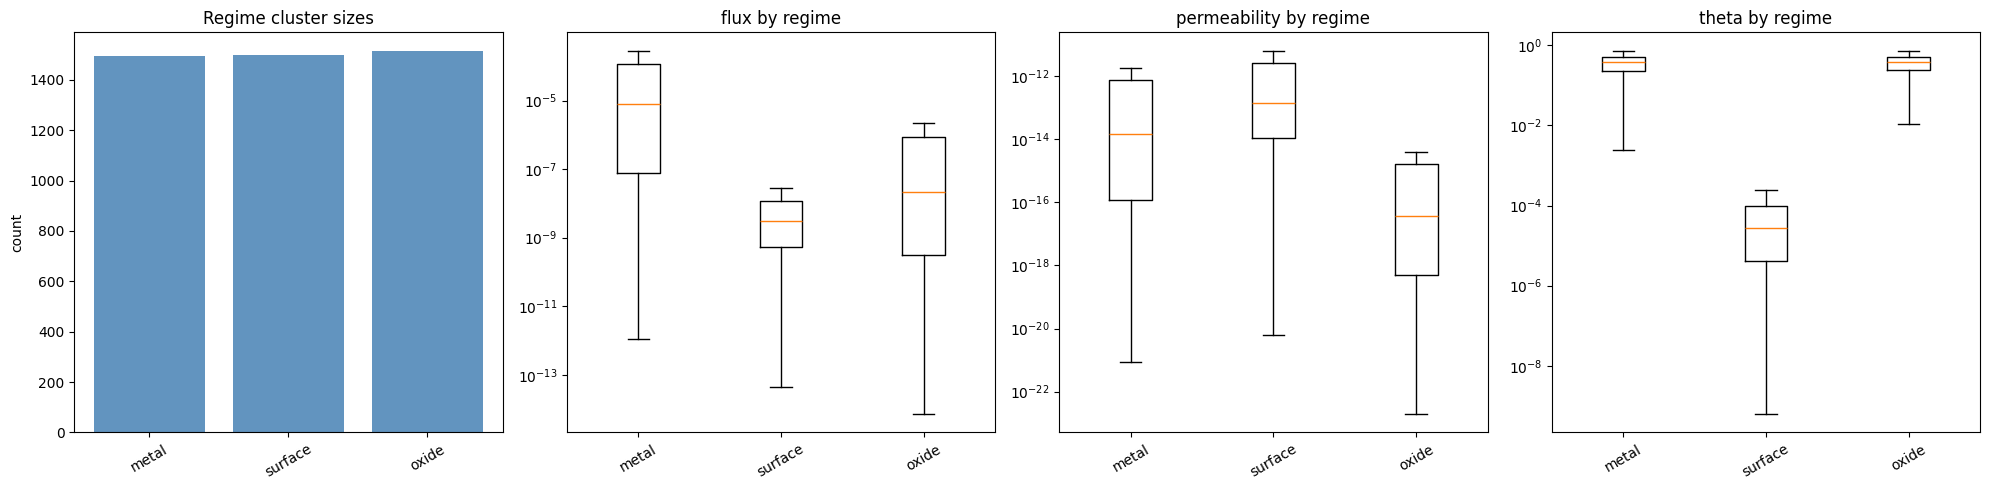


  regime (argmax)  ×  system_rate_limiting (solver):
system_rate_limiting  metal  mixed  oxide  surface
regime                                            
metal                  3329   1844     94       16
oxide                     0    778   1549        0
surface                  72    586      2      840


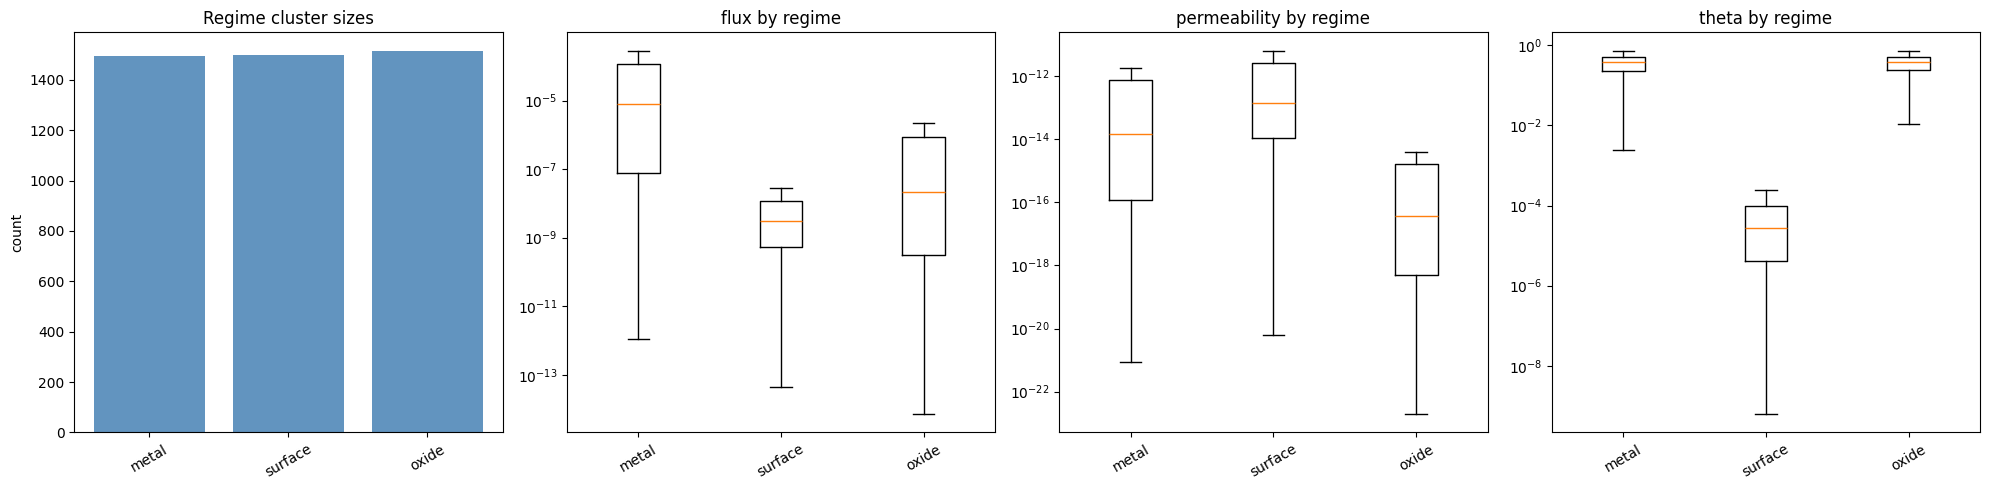

In [5]:
full_scan = pd.concat(scans.values(), ignore_index=True)
plot_regime_exploration(clusters, output_metrics=('flux', 'permeability', 'theta'),
                        scan_df=full_scan)

## Phase 2 — Route B (PRIMARY): given-data PAWN + δ on the true clusters

Zero extra model evaluations. Tidy results saved to `RESULTS_DIR/routeB_givendata.csv`.

In [6]:
gd = givendata_sensitivity_by_regime(clusters, PARAMS, output_metrics=METRICS,
                                     methods=('pawn', 'delta'), seed=SEED)
tidy = summarize_givendata(gd, PARAMS)
tidy.to_csv(os.path.join(RESULTS_DIR, "routeB_givendata.csv"), index=False)

for reg in clusters:
    sub = tidy[(tidy.regime == reg) & (tidy.metric == 'flux')].nlargest(8, 'delta')
    print(f"\n[{reg}] top-8 δ drivers of log10(flux):")
    print(sub[['parameter', 'delta', 'pawn_median', 'S1_givendata']].to_string(index=False))

  [metal/flux] n= 1495  top-δ param: temperature
  [metal/permeability] n= 1495  top-δ param: temperature
  [metal/theta] n= 1495  top-δ param: K_eq_ref
  [surface/flux] n= 1500  top-δ param: temperature
  [surface/permeability] n= 1500  top-δ param: temperature
  [surface/theta] n= 1500  top-δ param: H_sol_ox
  [oxide/flux] n= 1513  top-δ param: temperature
  [oxide/permeability] n= 1513  top-δ param: temperature
  [oxide/theta] n= 1513  top-δ param: K_eq_ref

[metal] top-8 δ drivers of log10(flux):
       parameter    delta  pawn_median  S1_givendata
     temperature 0.517460     0.504904      0.860788
      P_upstream 0.100871     0.093886      0.032970
       f_pinhole 0.097510     0.065610      0.008372
        H_sol_ox 0.092298     0.100323      0.011032
 lattice_density 0.091643     0.064742      0.006154
trap_vacancy_N_T 0.089983     0.099137      0.028047
trap_vacancy_E_b 0.087963     0.072805      0.008769
     f_gb_defect 0.086428     0.080662      0.006085

[surface] top-8 

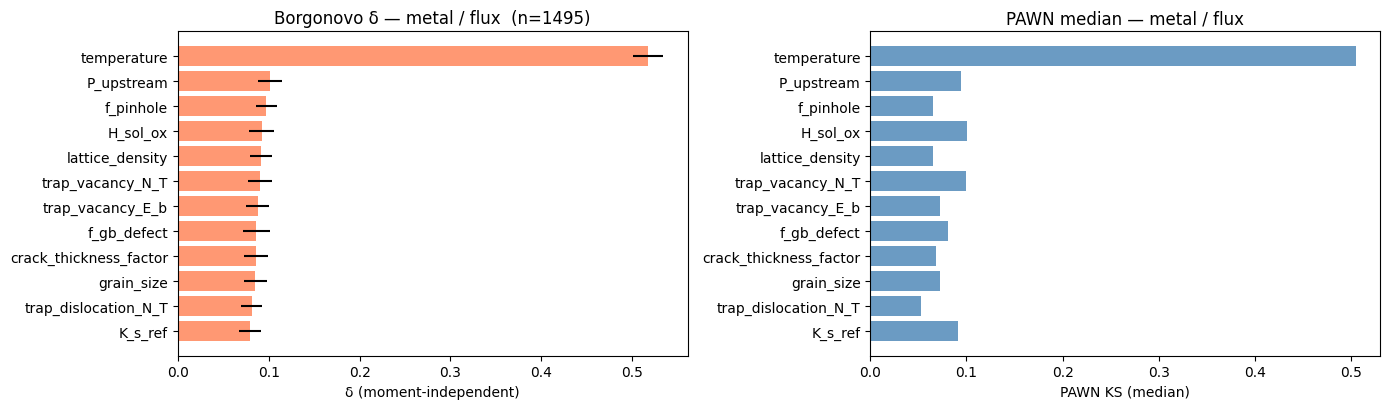

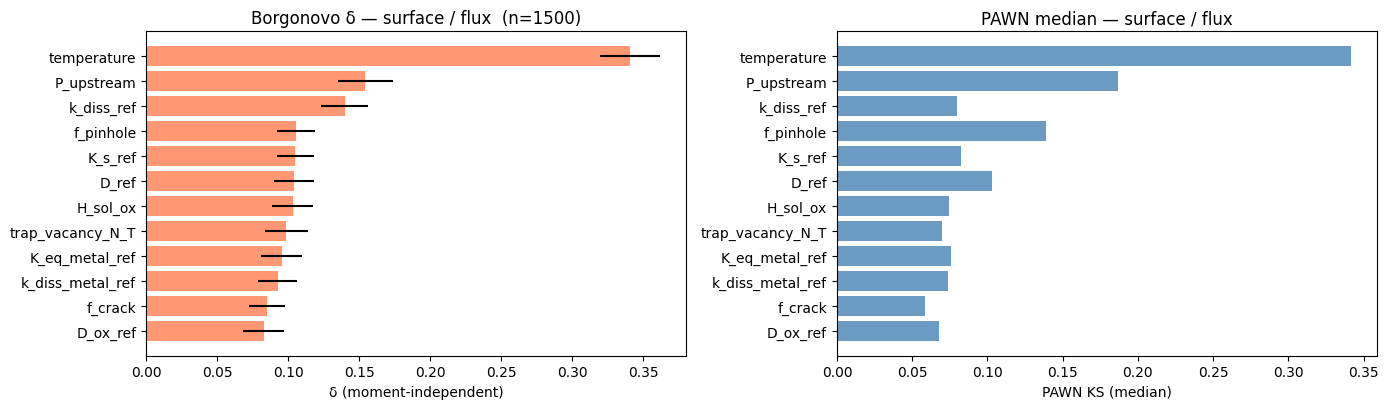

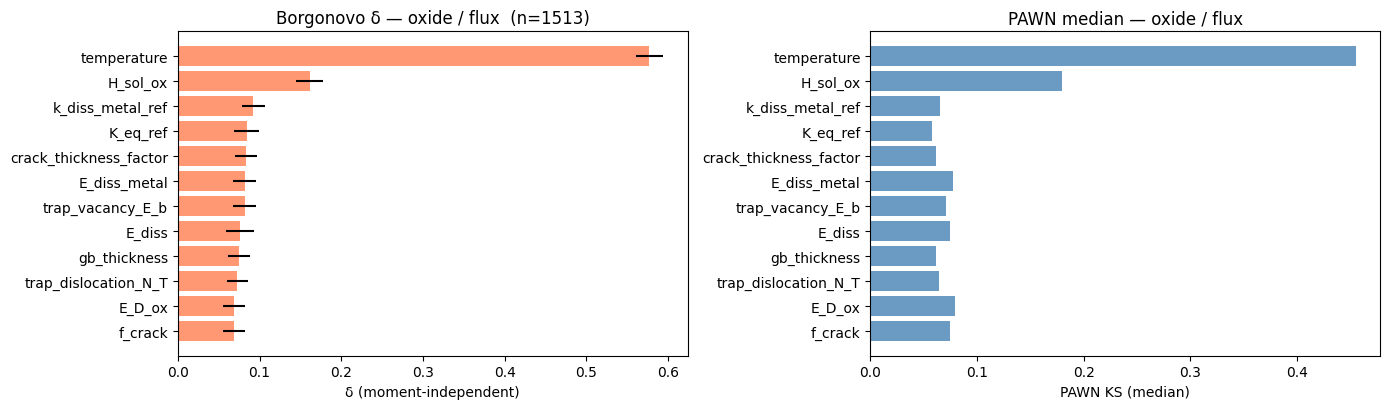

In [7]:
for reg in clusters:
    plot_givendata_results(gd, reg, 'flux', PARAMS, top_n=12)

## Phase 2 (cont.) — regime geometry

Where each cluster actually sits in parameter space, projected on that regime's two
strongest δ drivers. Dashed boxes are the 10–90 percentile band of the cluster. The
overlap between clusters is the visual reminder that regime boundaries are curved,
not rectangular.

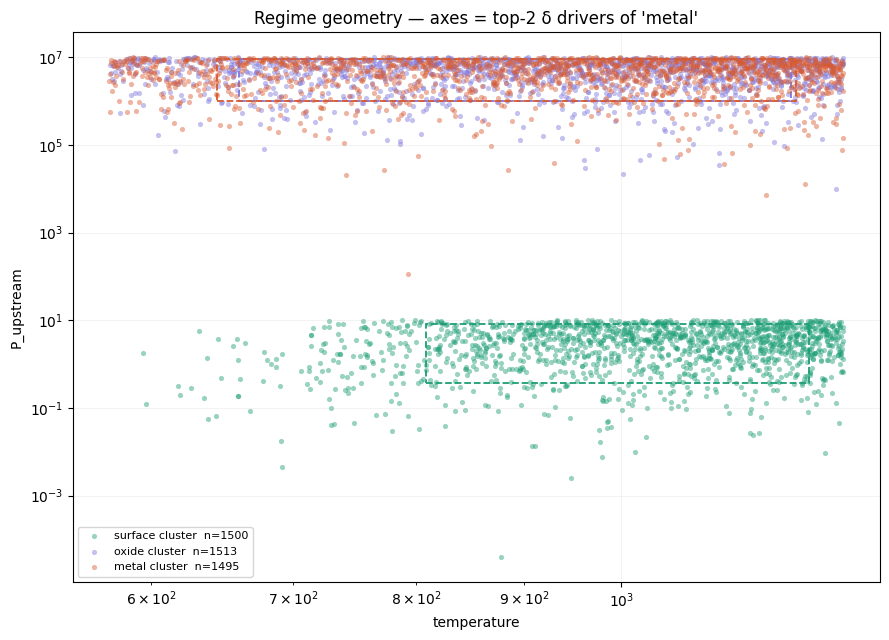

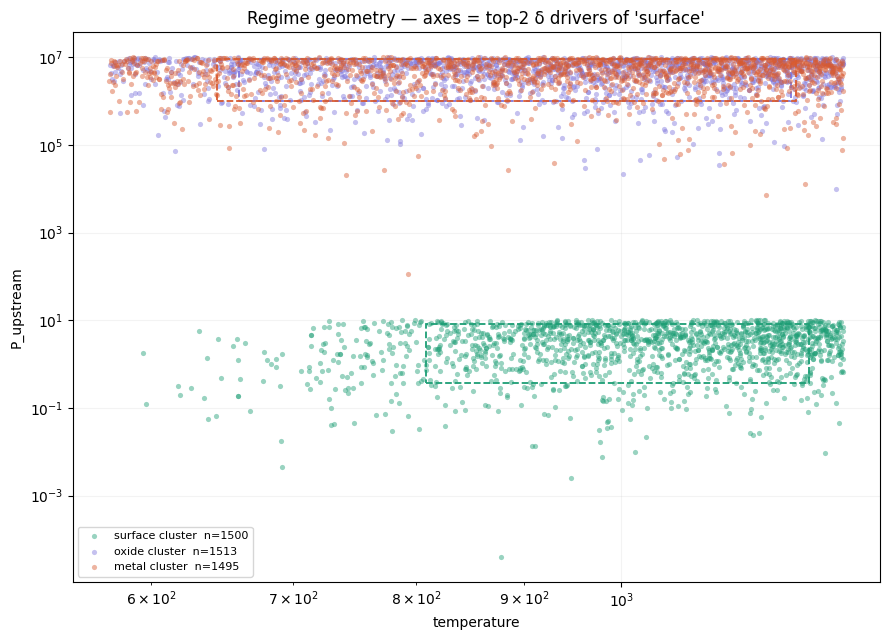

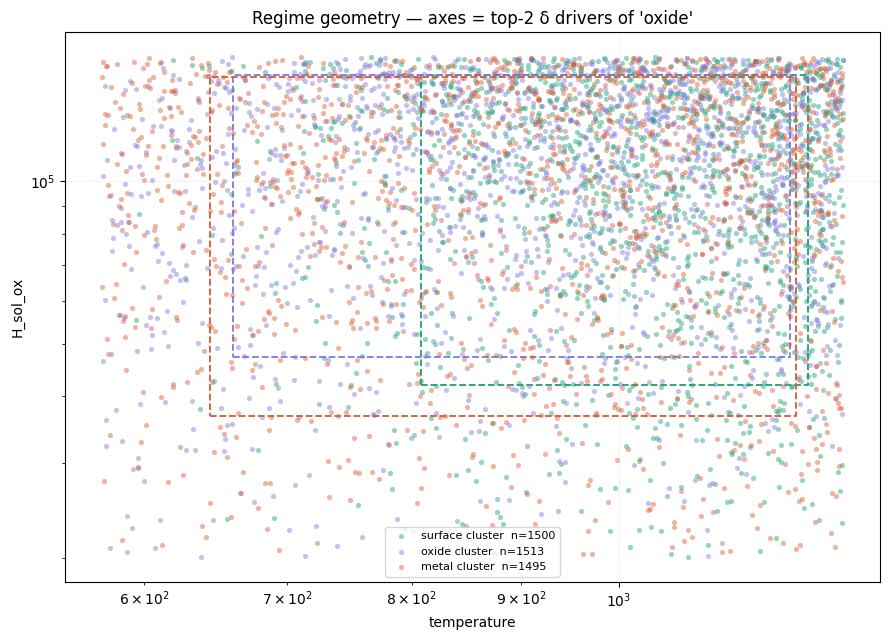

In [8]:
def regime_topk(reg, k=TOP_K, metric='flux'):
    """Top-k parameters for one regime, ranked by Route-B δ."""
    sub = tidy[(tidy.regime == reg) & (tidy.metric == metric)]
    return sub.nlargest(k, 'delta')['parameter'].tolist()

# most drivers span decades, so log axes by default — flip these off for E_a-type params
for reg in clusters:
    plot_regime_geometry(clusters, axes=regime_topk(reg)[:2], log_x=True, log_y=True,
                         title=f"Regime geometry — axes = top-2 δ drivers of '{reg}'")

## Phase 3 — Cross-regime comparison (saved)

Comparison matrices saved to `RESULTS_DIR/compare_<index>_<metric>.csv`.

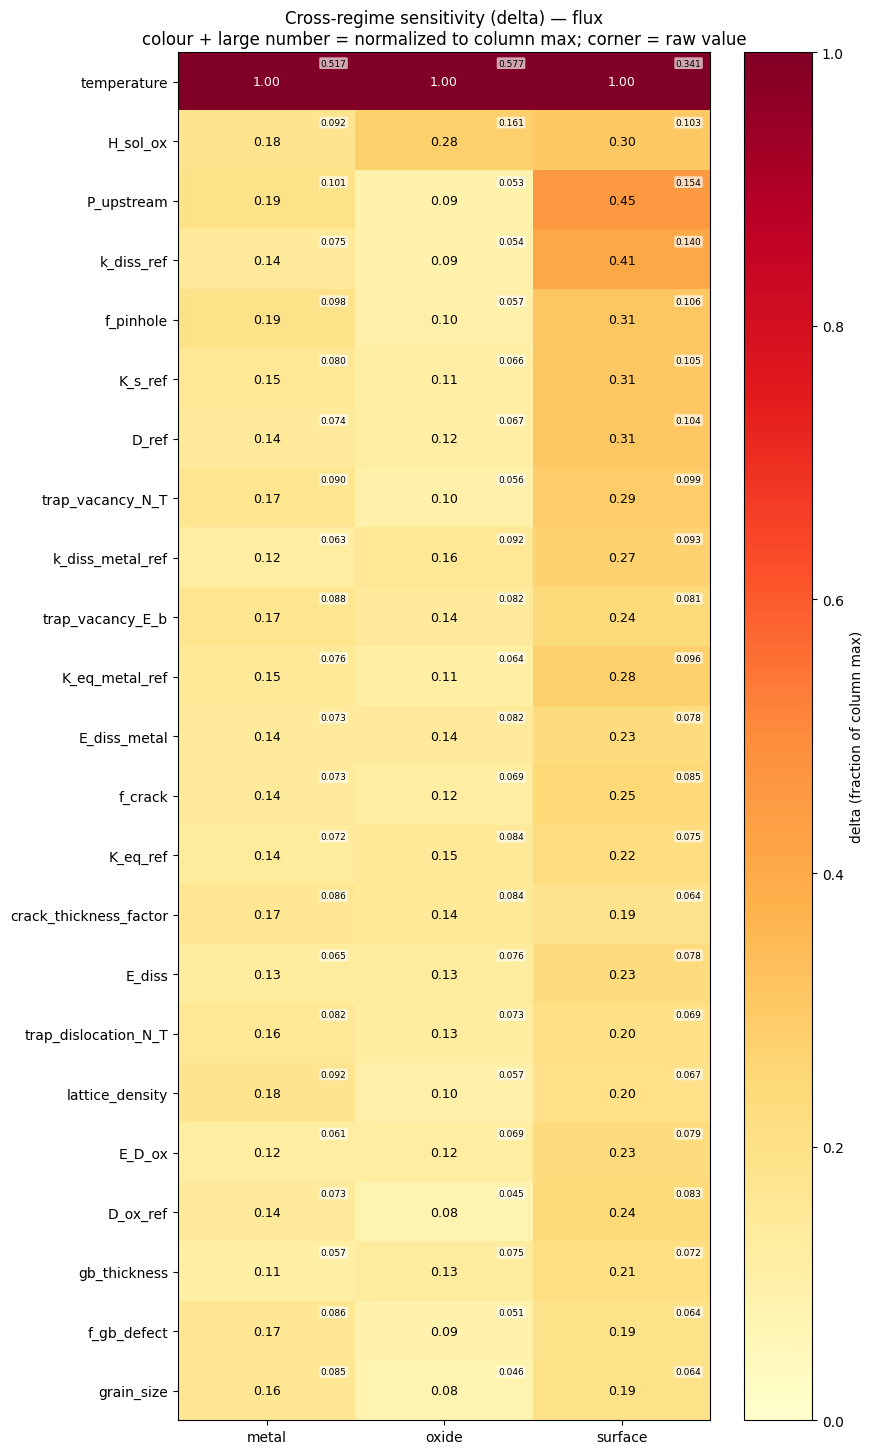

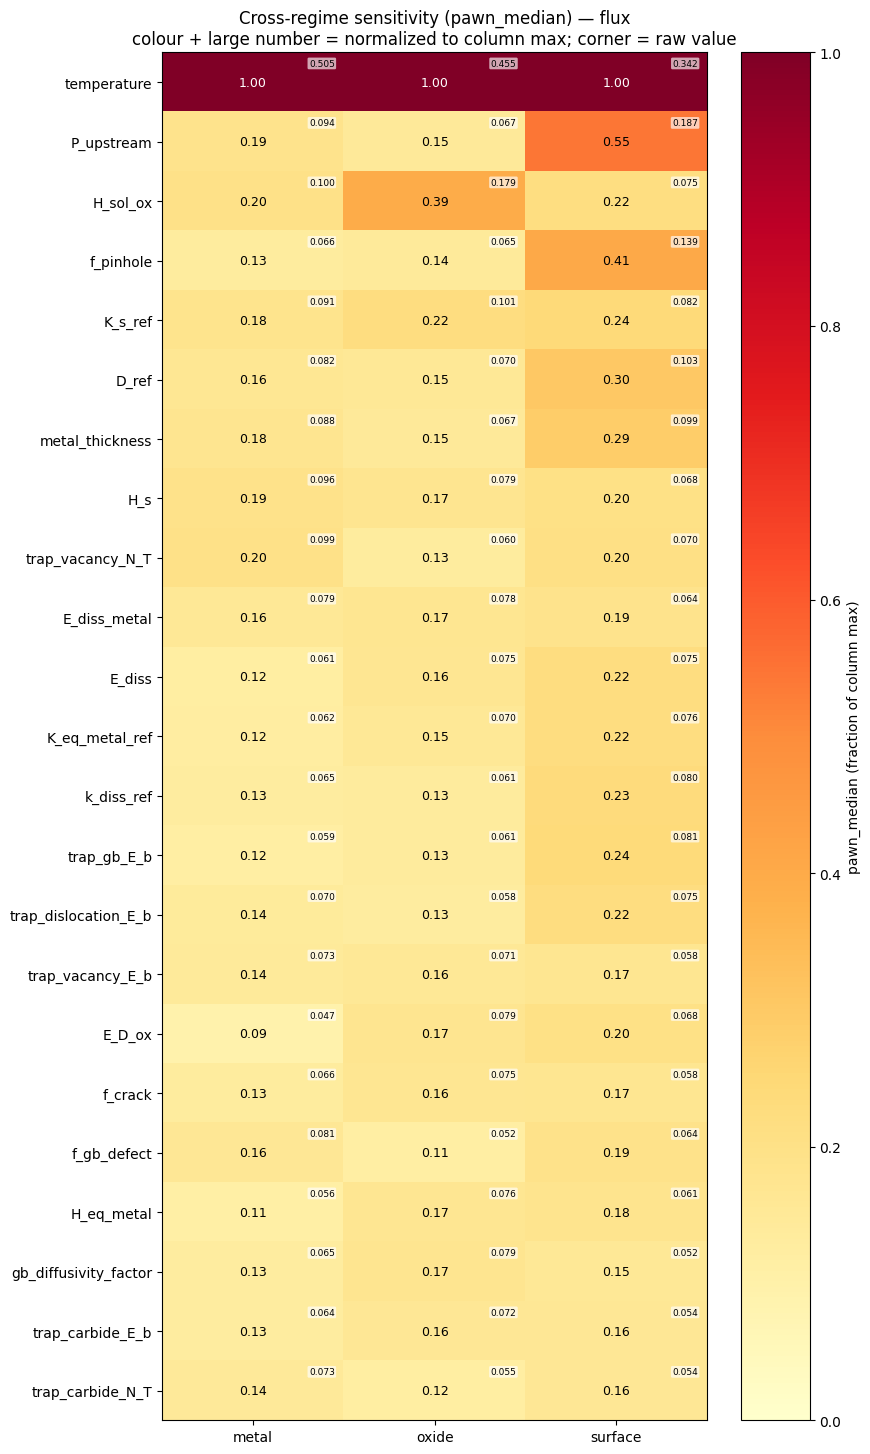

Cross-regime δ matrix (log10 flux):
regime                  metal  oxide  surface
parameter                                    
temperature             0.517  0.577    0.341
H_sol_ox                0.092  0.161    0.103
P_upstream              0.101  0.053    0.154
k_diss_ref              0.075  0.054    0.140
f_pinhole               0.098  0.057    0.106
trap_vacancy_E_b        0.088  0.082    0.081
K_s_ref                 0.080  0.066    0.105
k_diss_metal_ref        0.063  0.092    0.093
trap_vacancy_N_T        0.090  0.056    0.099
D_ref                   0.074  0.067    0.104
K_eq_metal_ref          0.076  0.064    0.096
crack_thickness_factor  0.086  0.084    0.064
E_diss_metal            0.073  0.082    0.078
K_eq_ref                0.072  0.084    0.075
f_crack                 0.073  0.069    0.085
trap_dislocation_N_T    0.082  0.073    0.069
E_diss                  0.065  0.076    0.078
lattice_density         0.092  0.057    0.067
E_D_ox                  0.061  0.069    0.07

In [9]:
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='delta', top_union=12)
plot_regime_comparison_heatmap(gd, 'flux', PARAMS, index='pawn_median', top_union=12)

for idx in ('delta', 'pawn_median'):
    for met in METRICS:
        mat = regime_comparison_matrix(gd, met, PARAMS, index=idx, top_union=12)
        if not mat.empty:
            mat.to_csv(os.path.join(RESULTS_DIR, f"compare_{idx}_{met}.csv"))

print("Cross-regime δ matrix (log10 flux):")
print(regime_comparison_matrix(gd, 'flux', PARAMS, index='delta', top_union=12).round(3).to_string())

In [10]:
# Manifest of everything saved
import glob
print("Saved CSV files under", os.path.abspath(RESULTS_DIR), ":")
for f in sorted(glob.glob(os.path.join(RESULTS_DIR, "**", "*.csv"), recursive=True)):
    print("  ", os.path.relpath(f, RESULTS_DIR), f"({os.path.getsize(f)//1024} KB)")

Saved CSV files under /Users/akinyemi.az/Desktop/HE_papers/yoshi/Analytical_model/MHI_permeation/Application/sa_results :
   compare_delta_flux.csv (1 KB)
   compare_delta_permeability.csv (1 KB)
   compare_delta_theta.csv (1 KB)
   compare_pawn_median_flux.csv (1 KB)
   compare_pawn_median_permeability.csv (1 KB)
   compare_pawn_median_theta.csv (1 KB)
   master_clusters.csv (4253 KB)
   routeB_givendata.csv (29 KB)
   scans/scan_metal.csv (1722 KB)
   scans/scan_oxide.csv (1890 KB)
   scans/scan_surface.csv (4915 KB)
